In [1]:
%load_ext autoreload

In [2]:
import pandas as pd
from ast import literal_eval
import protfasta
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import glob, os
from tqdm import tqdm

os.chdir("../../consensus_AD_predictor/notebooks/")
%aimport ADpred_LambertTFs_helper

In [3]:
output_folder = "/global/scratch/projects/fc_mvslab/OpenProjects/Sanjana/collaborations/GrENEnet_TF_hits/04_predictor_results/"
output_folder

'/global/scratch/projects/fc_mvslab/OpenProjects/Sanjana/collaborations/GrENEnet_TF_hits/04_predictor_results/'

In [4]:
glob.glob(output_folder + "*")

['/global/scratch/projects/fc_mvslab/OpenProjects/Sanjana/collaborations/GrENEnet_TF_hits/04_predictor_results/01c_tair_arabidopsis_cleaned_ADHunter_preds_dask.csv',
 '/global/scratch/projects/fc_mvslab/OpenProjects/Sanjana/collaborations/GrENEnet_TF_hits/04_predictor_results/activity_traces',
 '/global/scratch/projects/fc_mvslab/OpenProjects/Sanjana/collaborations/GrENEnet_TF_hits/04_predictor_results/all_prediction_intervals.csv',
 '/global/scratch/projects/fc_mvslab/OpenProjects/Sanjana/collaborations/GrENEnet_TF_hits/04_predictor_results/01c_tair_arabidopsis_cleaned_ADpred_preds_dask.csv',
 '/global/scratch/projects/fc_mvslab/OpenProjects/Sanjana/collaborations/GrENEnet_TF_hits/04_predictor_results/01c_tair_arabidopsis_cleaned_TADA_preds_dask.csv',
 '/global/scratch/projects/fc_mvslab/OpenProjects/Sanjana/collaborations/GrENEnet_TF_hits/04_predictor_results/01c_tair_arabidopsis_cleaned_Paddle_preds_dask.csv']

In [5]:
def read_and_parse_adpred(path):
    return pd.read_csv(path, converters={'adpred_preds': literal_eval}, index_col=0)

def parse_paddle(path):
    return pd.read_csv(path, converters = dict(paddle_centers=literal_eval,
                                        paddle_preds=literal_eval), index_col = 0)

def parse_adhunter(path):
    return pd.read_csv(path, converters = dict(
                                        adhunter_centers=literal_eval,
                                        adhunter_preds=literal_eval), index_col = 0)

def parse_tada(path):
    return pd.read_csv(path, converters = dict(tada_centers=literal_eval,
                                        tada_preds=literal_eval))

def return_preds(parse_function, paths):
    lview = c.load_balanced_view()
    lview.block = True 
    out = lview.map(parse_function, paths)   # Run calculation in parallel
    preds = pd.concat(out)
    return preds

In [6]:
adpred_preds = read_and_parse_adpred(output_folder + "01c_tair_arabidopsis_cleaned_ADpred_preds_dask.csv")
adpred_preds

,name,sequence,adpred_preds
0,LUL1,MGNLISLIFCCGRRQRSNIPPAMETAPLELPPNRFVFAAVPPYLNP...,"[0.010415409, 0.0044442494, 0.0038116248, 0.00..."
1,"ATNAP2,",MAEKNASAVDGAIRVSGMQFSYDVQDPIFFDFNLDLPAGSRCLLVG...,"[0.00017575947, 0.00022023142, 0.00026938823, ..."
2,"ACAM-2,",MADQLTDDQISEFKEAFSLFDKDGDGCITTKELGTVMRSLGQNPTE...,"[0.005517588, 0.0062822294, 0.027565049, 0.038..."
3,SRO2,MAAQVEIEDQTSVTNLDNGEIFDSISDDADSSVSHAGSSFSSSSLI...,"[0.0006666915, 0.0014921572, 0.0021866984, 0.0..."
4,"ALDH3I1,",MTKLLEINHIQTLCFAKGFSPARLNVATSPFRISRRGGGGYCSNAC...,"[0.01940209, 0.015027948, 0.0070035034, 0.0081..."
...,...,...,...
114,AAE18,MWKSIGELSCDDYVKAGLTLEDAKEFDKLVSDVITKAIETDPRDQW...,"[0.01186651, 0.010391192, 0.009314359, 0.03040..."
115,"RGA,",MKRDHHQFQGRLSNHGTSSSSSSISKDKMMMVKKEEDGGGNMDDEL...,"[7.433388e-05, 7.4474156e-05, 8.316777e-05, 6...."
116,"GAT,",MVVANDLSSKILPRVLIVSRRTLRKNKYVDFVGEYHLDLIVSSGAV...,"[0.0010794795, 0.0024175686, 0.005129668, 0.00..."
117,CPN10,MMKRLIPTFNRILVQRVIQPAKTESGILLPEKSSKLNSGKVIAVGP...,"[0.0014128906, 0.00049825537, 0.00037989885, 0..."


In [7]:
paddle_preds = parse_paddle(output_folder + "01c_tair_arabidopsis_cleaned_Paddle_preds_dask.csv")
paddle_preds

,name,sequence,paddle_centers,paddle_preds
0,LUL1,MGNLISLIFCCGRRQRSNIPPAMETAPLELPPNRFVFAAVPPYLNP...,"[27.0, 28.0, 29.0, 30.0, 31.0, 32.0, 33.0, 34....","[0.15544876, 0.19532509, 0.23359476, 0.2647924..."
1,"ATNAP2,",MAEKNASAVDGAIRVSGMQFSYDVQDPIFFDFNLDLPAGSRCLLVG...,"[27.0, 28.0, 29.0, 30.0, 31.0, 32.0, 33.0, 34....","[0.42032832, 0.37429157, 0.33517048, 0.3039736..."
2,"ACAM-2,",MADQLTDDQISEFKEAFSLFDKDGDGCITTKELGTVMRSLGQNPTE...,"[27.0, 28.0, 29.0, 30.0, 31.0, 32.0, 33.0, 34....","[6.0108314, 5.982242, 5.96787, 5.855394, 5.600..."
3,SRO2,MAAQVEIEDQTSVTNLDNGEIFDSISDDADSSVSHAGSSFSSSSLI...,"[27.0, 28.0, 29.0, 30.0, 31.0, 32.0, 33.0, 34....","[5.050518, 4.9765754, 4.791063, 4.674188, 4.53..."
4,"ALDH3I1,",MTKLLEINHIQTLCFAKGFSPARLNVATSPFRISRRGGGGYCSNAC...,"[27.0, 28.0, 29.0, 30.0, 31.0, 32.0, 33.0, 34....","[-0.04293575, -0.041265965, -0.039407153, -0.0..."
...,...,...,...,...
114,AAE18,MWKSIGELSCDDYVKAGLTLEDAKEFDKLVSDVITKAIETDPRDQW...,"[27.0, 28.0, 29.0, 30.0, 31.0, 32.0, 33.0, 34....","[3.5528107, 3.5127153, 3.4529169, 3.3460991, 3..."
115,"RGA,",MKRDHHQFQGRLSNHGTSSSSSSISKDKMMMVKKEEDGGGNMDDEL...,"[27.0, 28.0, 29.0, 30.0, 31.0, 32.0, 33.0, 34....","[0.50261563, 0.5287764, 0.52014744, 0.49027473..."
116,"GAT,",MVVANDLSSKILPRVLIVSRRTLRKNKYVDFVGEYHLDLIVSSGAV...,"[27.0, 28.0, 29.0, 30.0, 31.0, 32.0, 33.0, 34....","[-0.021341657, -0.023777446, -0.025681326, -0...."
117,CPN10,MMKRLIPTFNRILVQRVIQPAKTESGILLPEKSSKLNSGKVIAVGP...,"[27.0, 28.0, 29.0, 30.0, 31.0, 32.0, 33.0, 34....","[-0.1664454, -0.16317797, -0.16314755, -0.1641..."


In [8]:
adhunter_preds = parse_adhunter(output_folder + "01c_tair_arabidopsis_cleaned_ADHunter_preds_dask.csv")
adhunter_preds

,name,sequence,adhunter_centers,adhunter_preds
0,LUL1,MGNLISLIFCCGRRQRSNIPPAMETAPLELPPNRFVFAAVPPYLNP...,"[20.0, 21.0, 22.0, 23.0, 24.0, 25.0, 26.0, 27....","[66301.375, 62624.504, 61641.316, 63505.227, 6..."
1,"ATNAP2,",MAEKNASAVDGAIRVSGMQFSYDVQDPIFFDFNLDLPAGSRCLLVG...,"[20.0, 21.0, 22.0, 23.0, 24.0, 25.0, 26.0, 27....","[175402.61, 159846.0, 170251.3, 188025.55, 203..."
2,"ACAM-2,",MADQLTDDQISEFKEAFSLFDKDGDGCITTKELGTVMRSLGQNPTE...,"[20.0, 21.0, 22.0, 23.0, 24.0, 25.0, 26.0, 27....","[47999.938, 41500.12, 45614.613, 44372.336, 34..."
3,SRO2,MAAQVEIEDQTSVTNLDNGEIFDSISDDADSSVSHAGSSFSSSSLI...,"[20.0, 21.0, 22.0, 23.0, 24.0, 25.0, 26.0, 27....","[34717.56, 28908.691, 26254.004, 25919.578, 23..."
4,"ALDH3I1,",MTKLLEINHIQTLCFAKGFSPARLNVATSPFRISRRGGGGYCSNAC...,"[20.0, 21.0, 22.0, 23.0, 24.0, 25.0, 26.0, 27....","[36806.44, 37728.484, 44039.215, 44791.92, 443..."
...,...,...,...,...
114,AAE18,MWKSIGELSCDDYVKAGLTLEDAKEFDKLVSDVITKAIETDPRDQW...,"[20.0, 21.0, 22.0, 23.0, 24.0, 25.0, 26.0, 27....","[43271.863, 40571.44, 37786.59, 40486.746, 367..."
115,"RGA,",MKRDHHQFQGRLSNHGTSSSSSSISKDKMMMVKKEEDGGGNMDDEL...,"[20.0, 21.0, 22.0, 23.0, 24.0, 25.0, 26.0, 27....","[21403.242, 21672.602, 21693.078, 21639.781, 2..."
116,"GAT,",MVVANDLSSKILPRVLIVSRRTLRKNKYVDFVGEYHLDLIVSSGAV...,"[20.0, 21.0, 22.0, 23.0, 24.0, 25.0, 26.0, 27....","[47272.85, 54549.15, 66408.89, 63218.645, 4857..."
117,CPN10,MMKRLIPTFNRILVQRVIQPAKTESGILLPEKSSKLNSGKVIAVGP...,"[20.0, 21.0, 22.0, 23.0, 24.0, 25.0, 26.0, 27....","[30002.547, 34553.418, 46212.74, 57877.164, 62..."


In [9]:
tada_preds = parse_tada(output_folder + "01c_tair_arabidopsis_cleaned_TADA_preds_dask.csv")
tada_preds

,Unnamed: 0,name,sequence,tada_centers,tada_preds
0,0,LUL1,MGNLISLIFCCGRRQRSNIPPAMETAPLELPPNRFVFAAVPPYLNP...,"[20.0, 21.0, 22.0, 23.0, 24.0, 25.0, 26.0, 27....","[0.18833423, 0.18431997, 0.18328969, 0.1929323..."
1,1,"ATNAP2,",MAEKNASAVDGAIRVSGMQFSYDVQDPIFFDFNLDLPAGSRCLLVG...,"[20.0, 21.0, 22.0, 23.0, 24.0, 25.0, 26.0, 27....","[0.5876344, 0.5758871, 0.57207966, 0.575493, 0..."
2,2,"ACAM-2,",MADQLTDDQISEFKEAFSLFDKDGDGCITTKELGTVMRSLGQNPTE...,"[20.0, 21.0, 22.0, 23.0, 24.0, 25.0, 26.0, 27....","[0.43950447, 0.4375867, 0.42697394, 0.41731757..."
3,3,SRO2,MAAQVEIEDQTSVTNLDNGEIFDSISDDADSSVSHAGSSFSSSSLI...,"[20.0, 21.0, 22.0, 23.0, 24.0, 25.0, 26.0, 27....","[0.3039948, 0.32357755, 0.34019348, 0.33868453..."
4,4,"ALDH3I1,",MTKLLEINHIQTLCFAKGFSPARLNVATSPFRISRRGGGGYCSNAC...,"[20.0, 21.0, 22.0, 23.0, 24.0, 25.0, 26.0, 27....","[0.16569784, 0.1709359, 0.17375883, 0.16575304..."
...,...,...,...,...,...
114,114,AAE18,MWKSIGELSCDDYVKAGLTLEDAKEFDKLVSDVITKAIETDPRDQW...,"[20.0, 21.0, 22.0, 23.0, 24.0, 25.0, 26.0, 27....","[0.30681333, 0.31209317, 0.3504698, 0.30963716..."
115,115,"RGA,",MKRDHHQFQGRLSNHGTSSSSSSISKDKMMMVKKEEDGGGNMDDEL...,"[20.0, 21.0, 22.0, 23.0, 24.0, 25.0, 26.0, 27....","[0.15320298, 0.1480531, 0.15073039, 0.15742622..."
116,116,"GAT,",MVVANDLSSKILPRVLIVSRRTLRKNKYVDFVGEYHLDLIVSSGAV...,"[20.0, 21.0, 22.0, 23.0, 24.0, 25.0, 26.0, 27....","[0.19093429, 0.18834545, 0.18690503, 0.1820799..."
117,117,CPN10,MMKRLIPTFNRILVQRVIQPAKTESGILLPEKSSKLNSGKVIAVGP...,"[20.0, 21.0, 22.0, 23.0, 24.0, 25.0, 26.0, 27....","[0.15468897, 0.15133703, 0.15573773, 0.1668505..."


In [10]:
preds = (
    adpred_preds
    .merge(paddle_preds, on=["name", "sequence"])
    .merge(adhunter_preds, on=["name", "sequence"])
    .merge(tada_preds[["sequence", "tada_centers", "tada_preds"]], on=["sequence"])
)
preds

,name,sequence,adpred_preds,paddle_centers,paddle_preds,adhunter_centers,adhunter_preds,tada_centers,tada_preds
0,LUL1,MGNLISLIFCCGRRQRSNIPPAMETAPLELPPNRFVFAAVPPYLNP...,"[0.010415409, 0.0044442494, 0.0038116248, 0.00...","[27.0, 28.0, 29.0, 30.0, 31.0, 32.0, 33.0, 34....","[0.15544876, 0.19532509, 0.23359476, 0.2647924...","[20.0, 21.0, 22.0, 23.0, 24.0, 25.0, 26.0, 27....","[66301.375, 62624.504, 61641.316, 63505.227, 6...","[20.0, 21.0, 22.0, 23.0, 24.0, 25.0, 26.0, 27....","[0.18833423, 0.18431997, 0.18328969, 0.1929323..."
1,"ATNAP2,",MAEKNASAVDGAIRVSGMQFSYDVQDPIFFDFNLDLPAGSRCLLVG...,"[0.00017575947, 0.00022023142, 0.00026938823, ...","[27.0, 28.0, 29.0, 30.0, 31.0, 32.0, 33.0, 34....","[0.42032832, 0.37429157, 0.33517048, 0.3039736...","[20.0, 21.0, 22.0, 23.0, 24.0, 25.0, 26.0, 27....","[175402.61, 159846.0, 170251.3, 188025.55, 203...","[20.0, 21.0, 22.0, 23.0, 24.0, 25.0, 26.0, 27....","[0.5876344, 0.5758871, 0.57207966, 0.575493, 0..."
2,"ACAM-2,",MADQLTDDQISEFKEAFSLFDKDGDGCITTKELGTVMRSLGQNPTE...,"[0.005517588, 0.0062822294, 0.027565049, 0.038...","[27.0, 28.0, 29.0, 30.0, 31.0, 32.0, 33.0, 34....","[6.0108314, 5.982242, 5.96787, 5.855394, 5.600...","[20.0, 21.0, 22.0, 23.0, 24.0, 25.0, 26.0, 27....","[47999.938, 41500.12, 45614.613, 44372.336, 34...","[20.0, 21.0, 22.0, 23.0, 24.0, 25.0, 26.0, 27....","[0.43950447, 0.4375867, 0.42697394, 0.41731757..."
3,SRO2,MAAQVEIEDQTSVTNLDNGEIFDSISDDADSSVSHAGSSFSSSSLI...,"[0.0006666915, 0.0014921572, 0.0021866984, 0.0...","[27.0, 28.0, 29.0, 30.0, 31.0, 32.0, 33.0, 34....","[5.050518, 4.9765754, 4.791063, 4.674188, 4.53...","[20.0, 21.0, 22.0, 23.0, 24.0, 25.0, 26.0, 27....","[34717.56, 28908.691, 26254.004, 25919.578, 23...","[20.0, 21.0, 22.0, 23.0, 24.0, 25.0, 26.0, 27....","[0.3039948, 0.32357755, 0.34019348, 0.33868453..."
4,"ALDH3I1,",MTKLLEINHIQTLCFAKGFSPARLNVATSPFRISRRGGGGYCSNAC...,"[0.01940209, 0.015027948, 0.0070035034, 0.0081...","[27.0, 28.0, 29.0, 30.0, 31.0, 32.0, 33.0, 34....","[-0.04293575, -0.041265965, -0.039407153, -0.0...","[20.0, 21.0, 22.0, 23.0, 24.0, 25.0, 26.0, 27....","[36806.44, 37728.484, 44039.215, 44791.92, 443...","[20.0, 21.0, 22.0, 23.0, 24.0, 25.0, 26.0, 27....","[0.16569784, 0.1709359, 0.17375883, 0.16575304..."
...,...,...,...,...,...,...,...,...,...
114,AAE18,MWKSIGELSCDDYVKAGLTLEDAKEFDKLVSDVITKAIETDPRDQW...,"[0.01186651, 0.010391192, 0.009314359, 0.03040...","[27.0, 28.0, 29.0, 30.0, 31.0, 32.0, 33.0, 34....","[3.5528107, 3.5127153, 3.4529169, 3.3460991, 3...","[20.0, 21.0, 22.0, 23.0, 24.0, 25.0, 26.0, 27....","[43271.863, 40571.44, 37786.59, 40486.746, 367...","[20.0, 21.0, 22.0, 23.0, 24.0, 25.0, 26.0, 27....","[0.30681333, 0.31209317, 0.3504698, 0.30963716..."
115,"RGA,",MKRDHHQFQGRLSNHGTSSSSSSISKDKMMMVKKEEDGGGNMDDEL...,"[7.433388e-05, 7.4474156e-05, 8.316777e-05, 6....","[27.0, 28.0, 29.0, 30.0, 31.0, 32.0, 33.0, 34....","[0.50261563, 0.5287764, 0.52014744, 0.49027473...","[20.0, 21.0, 22.0, 23.0, 24.0, 25.0, 26.0, 27....","[21403.242, 21672.602, 21693.078, 21639.781, 2...","[20.0, 21.0, 22.0, 23.0, 24.0, 25.0, 26.0, 27....","[0.15320298, 0.1480531, 0.15073039, 0.15742622..."
116,"GAT,",MVVANDLSSKILPRVLIVSRRTLRKNKYVDFVGEYHLDLIVSSGAV...,"[0.0010794795, 0.0024175686, 0.005129668, 0.00...","[27.0, 28.0, 29.0, 30.0, 31.0, 32.0, 33.0, 34....","[-0.021341657, -0.023777446, -0.025681326, -0....","[20.0, 21.0, 22.0, 23.0, 24.0, 25.0, 26.0, 27....","[47272.85, 54549.15, 66408.89, 63218.645, 4857...","[20.0, 21.0, 22.0, 23.0, 24.0, 25.0, 26.0, 27....","[0.19093429, 0.18834545, 0.18690503, 0.1820799..."
117,CPN10,MMKRLIPTFNRILVQRVIQPAKTESGILLPEKSSKLNSGKVIAVGP...,"[0.0014128906, 0.00049825537, 0.00037989885, 0...","[27.0, 28.0, 29.0, 30.0, 31.0, 32.0, 33.0, 34....","[-0.1664454, -0.16317797, -0.16314755, -0.1641...","[20.0, 21.0, 22.0, 23.0, 24.0, 25.0, 26.0, 27....","[30002.547, 34553.418, 46212.74, 57877.164, 62...","[20.0, 21.0, 22.0, 23.0, 24.0, 25.0, 26.0, 27....","[0.15468897, 0.15133703, 0.15573773, 0.1668505..."


In [76]:
preds["name"].value_counts()

name
QSOX1,     1
LUL1       1
ATNAP2,    1
ACAM-2,    1
SRO2       1
          ..
ERF109,    1
CAD-5,     1
PERK5,     1
CIB1       1
KCS17      1
Name: count, Length: 119, dtype: int64

In [31]:
seqs = pd.read_csv("/global/scratch/projects/fc_mvslab/OpenProjects/Sanjana/collaborations/GrENEnet_TF_hits/01d_tair_arabidopsis_cleaned.csv", index_col = 0)
seqs = seqs.rename(columns = {"seq_cleaned" : "sequence"})
seqs

,id,seq,gene,tair_ID,sequence
0,AT5G03200.1 | Symbols: LUL1 | LOG2-LIKE UBIQUI...,MGNLISLIFCCGRRQRSNIPPAMETAPLELPPNRFVFAAVPPYLNP...,LUL1,AT5G03200.1,MGNLISLIFCCGRRQRSNIPPAMETAPLELPPNRFVFAAVPPYLNP...
1,"AT5G44110.1 | Symbols: ATNAP2, POP1, ABCI21, A...",MAEKNASAVDGAIRVSGMQFSYDVQDPIFFDFNLDLPAGSRCLLVG...,"ATNAP2, POP1, ABCI21, ATPOP1",AT5G44110.1,MAEKNASAVDGAIRVSGMQFSYDVQDPIFFDFNLDLPAGSRCLLVG...
2,"AT2G27030.3 | Symbols: ACAM-2, CAM5 | calmodul...",MADQLTDDQISEFKEAFSLFDKDGDGCITTKELGTVMRSLGQNPTE...,"ACAM-2, CAM5",AT2G27030.3,MADQLTDDQISEFKEAFSLFDKDGDGCITTKELGTVMRSLGQNPTE...
3,AT1G23550.1 | Symbols: SRO2 | similar to RCD o...,MAAQVEIEDQTSVTNLDNGEIFDSISDDADSSVSHAGSSFSSSSLI...,SRO2,AT1G23550.1,MAAQVEIEDQTSVTNLDNGEIFDSISDDADSSVSHAGSSFSSSSLI...
4,"AT4G34240.1 | Symbols: ALDH3I1, ALDH3 | aldehy...",MTKLLEINHIQTLCFAKGFSPARLNVATSPFRISRRGGGGYCSNAC...,"ALDH3I1, ALDH3",AT4G34240.1,MTKLLEINHIQTLCFAKGFSPARLNVATSPFRISRRGGGGYCSNAC...
...,...,...,...,...,...
114,AT1G55320.1 | Symbols: AAE18 | acyl-activating...,MWKSIGELSCDDYVKAGLTLEDAKEFDKLVSDVITKAIETDPRDQW...,AAE18,AT1G55320.1,MWKSIGELSCDDYVKAGLTLEDAKEFDKLVSDVITKAIETDPRDQW...
115,"AT2G01570.1 | Symbols: RGA, RGA1, RGA24 | REPR...",MKRDHHQFQGRLSNHGTSSSSSSISKDKMMMVKKEEDGGGNMDDEL...,"RGA, RGA1, RGA24",AT2G01570.1,MKRDHHQFQGRLSNHGTSSSSSSISKDKMMMVKKEEDGGGNMDDEL...
116,"AT1G15040.1 | Symbols: GAT, GAT1_2.1 | glutami...",MVVANDLSSKILPRVLIVSRRTLRKNKYVDFVGEYHLDLIVSSGAV...,"GAT, GAT1_2.1",AT1G15040.1,MVVANDLSSKILPRVLIVSRRTLRKNKYVDFVGEYHLDLIVSSGAV...
117,AT1G14980.1 | Symbols: CPN10 | chaperonin 10 |...,MMKRLIPTFNRILVQRVIQPAKTESGILLPEKSSKLNSGKVIAVGP...,CPN10,AT1G14980.1,MMKRLIPTFNRILVQRVIQPAKTESGILLPEKSSKLNSGKVIAVGP...


In [32]:
preds = pd.merge(preds, seqs[["sequence", "tair_ID"]])
preds

,name,sequence,adpred_preds,paddle_centers,paddle_preds,adhunter_centers,adhunter_preds,tada_centers,tada_preds,tair_ID
0,LUL1,MGNLISLIFCCGRRQRSNIPPAMETAPLELPPNRFVFAAVPPYLNP...,"[0.010415409, 0.0044442494, 0.0038116248, 0.00...","[27.0, 28.0, 29.0, 30.0, 31.0, 32.0, 33.0, 34....","[0.15544876, 0.19532509, 0.23359476, 0.2647924...","[20.0, 21.0, 22.0, 23.0, 24.0, 25.0, 26.0, 27....","[66301.375, 62624.504, 61641.316, 63505.227, 6...","[20.0, 21.0, 22.0, 23.0, 24.0, 25.0, 26.0, 27....","[0.18833423, 0.18431997, 0.18328969, 0.1929323...",AT5G03200.1
1,"ATNAP2,",MAEKNASAVDGAIRVSGMQFSYDVQDPIFFDFNLDLPAGSRCLLVG...,"[0.00017575947, 0.00022023142, 0.00026938823, ...","[27.0, 28.0, 29.0, 30.0, 31.0, 32.0, 33.0, 34....","[0.42032832, 0.37429157, 0.33517048, 0.3039736...","[20.0, 21.0, 22.0, 23.0, 24.0, 25.0, 26.0, 27....","[175402.61, 159846.0, 170251.3, 188025.55, 203...","[20.0, 21.0, 22.0, 23.0, 24.0, 25.0, 26.0, 27....","[0.5876344, 0.5758871, 0.57207966, 0.575493, 0...",AT5G44110.1
2,"ACAM-2,",MADQLTDDQISEFKEAFSLFDKDGDGCITTKELGTVMRSLGQNPTE...,"[0.005517588, 0.0062822294, 0.027565049, 0.038...","[27.0, 28.0, 29.0, 30.0, 31.0, 32.0, 33.0, 34....","[6.0108314, 5.982242, 5.96787, 5.855394, 5.600...","[20.0, 21.0, 22.0, 23.0, 24.0, 25.0, 26.0, 27....","[47999.938, 41500.12, 45614.613, 44372.336, 34...","[20.0, 21.0, 22.0, 23.0, 24.0, 25.0, 26.0, 27....","[0.43950447, 0.4375867, 0.42697394, 0.41731757...",AT2G27030.3
3,SRO2,MAAQVEIEDQTSVTNLDNGEIFDSISDDADSSVSHAGSSFSSSSLI...,"[0.0006666915, 0.0014921572, 0.0021866984, 0.0...","[27.0, 28.0, 29.0, 30.0, 31.0, 32.0, 33.0, 34....","[5.050518, 4.9765754, 4.791063, 4.674188, 4.53...","[20.0, 21.0, 22.0, 23.0, 24.0, 25.0, 26.0, 27....","[34717.56, 28908.691, 26254.004, 25919.578, 23...","[20.0, 21.0, 22.0, 23.0, 24.0, 25.0, 26.0, 27....","[0.3039948, 0.32357755, 0.34019348, 0.33868453...",AT1G23550.1
4,"ALDH3I1,",MTKLLEINHIQTLCFAKGFSPARLNVATSPFRISRRGGGGYCSNAC...,"[0.01940209, 0.015027948, 0.0070035034, 0.0081...","[27.0, 28.0, 29.0, 30.0, 31.0, 32.0, 33.0, 34....","[-0.04293575, -0.041265965, -0.039407153, -0.0...","[20.0, 21.0, 22.0, 23.0, 24.0, 25.0, 26.0, 27....","[36806.44, 37728.484, 44039.215, 44791.92, 443...","[20.0, 21.0, 22.0, 23.0, 24.0, 25.0, 26.0, 27....","[0.16569784, 0.1709359, 0.17375883, 0.16575304...",AT4G34240.1
...,...,...,...,...,...,...,...,...,...,...
114,AAE18,MWKSIGELSCDDYVKAGLTLEDAKEFDKLVSDVITKAIETDPRDQW...,"[0.01186651, 0.010391192, 0.009314359, 0.03040...","[27.0, 28.0, 29.0, 30.0, 31.0, 32.0, 33.0, 34....","[3.5528107, 3.5127153, 3.4529169, 3.3460991, 3...","[20.0, 21.0, 22.0, 23.0, 24.0, 25.0, 26.0, 27....","[43271.863, 40571.44, 37786.59, 40486.746, 367...","[20.0, 21.0, 22.0, 23.0, 24.0, 25.0, 26.0, 27....","[0.30681333, 0.31209317, 0.3504698, 0.30963716...",AT1G55320.1
115,"RGA,",MKRDHHQFQGRLSNHGTSSSSSSISKDKMMMVKKEEDGGGNMDDEL...,"[7.433388e-05, 7.4474156e-05, 8.316777e-05, 6....","[27.0, 28.0, 29.0, 30.0, 31.0, 32.0, 33.0, 34....","[0.50261563, 0.5287764, 0.52014744, 0.49027473...","[20.0, 21.0, 22.0, 23.0, 24.0, 25.0, 26.0, 27....","[21403.242, 21672.602, 21693.078, 21639.781, 2...","[20.0, 21.0, 22.0, 23.0, 24.0, 25.0, 26.0, 27....","[0.15320298, 0.1480531, 0.15073039, 0.15742622...",AT2G01570.1
116,"GAT,",MVVANDLSSKILPRVLIVSRRTLRKNKYVDFVGEYHLDLIVSSGAV...,"[0.0010794795, 0.0024175686, 0.005129668, 0.00...","[27.0, 28.0, 29.0, 30.0, 31.0, 32.0, 33.0, 34....","[-0.021341657, -0.023777446, -0.025681326, -0....","[20.0, 21.0, 22.0, 23.0, 24.0, 25.0, 26.0, 27....","[47272.85, 54549.15, 66408.89, 63218.645, 4857...","[20.0, 21.0, 22.0, 23.0, 24.0, 25.0, 26.0, 27....","[0.19093429, 0.18834545, 0.18690503, 0.1820799...",AT1G15040.1
117,CPN10,MMKRLIPTFNRILVQRVIQPAKTESGILLPEKSSKLNSGKVIAVGP...,"[0.0014128906, 0.00049825537, 0.00037989885, 0...","[27.0, 28.0, 29.0, 30.0, 31.0, 32.0, 33.0, 34....","[-0.1664454, -0.16317797, -0.16314755, -0.1641...","[20.0, 21.0, 22.0, 23.0, 24.0, 25.0, 26.0, 27....","[30002.547, 34553.418, 46212.74, 57877.164, 62...","[20.0, 21.0, 22.0, 23.0,

# ADPred preds

In [77]:
# At least 10 positions above 0.8
df_list = []

for i in tqdm(range(len(preds.index)), desc="Processing ADPred"):
    df_list.append(
        ADpred_LambertTFs_helper.return_pred_df(
            preds["adpred_preds"][i], 
            0.8, 
            10,
            preds["sequence"][i],
            preds["name"][i]
        )
    )

adpred_intervals = pd.concat(df_list)
adpred_intervals["uniprotID"] = adpred_intervals["GeneName"]#.str.split("|").str[1]
adpred_intervals = adpred_intervals[["uniprotID", "Start", "End"]]
adpred_intervals["predictor"] = "ADPred"
adpred_intervals = adpred_intervals.reset_index(drop=True)
adpred_intervals

Processing ADPred: 100%|██████████| 119/119 [00:00<00:00, 3989.91it/s]


,uniprotID,Start,End,predictor
0,"ATNAP2,",17.0,37.0,ADPred
1,"ATNAP2,",174.0,189.0,ADPred
2,"ACAM-2,",55.0,64.0,ADPred
3,"ATGLR2.4,",495.0,508.0,ADPred
4,"CSN5B,",227.0,240.0,ADPred
...,...,...,...,...
111,AAE18,391.0,402.0,ADPred
112,"RGA,",85.0,111.0,ADPred
113,"RGA,",462.0,482.0,ADPred
114,"QSOX1,",194.0,204.0,ADPred


# PADDLE

In [78]:
def true_intervals_longer_than_5(bool_list):
    intervals = []
    start = None

    for i, val in enumerate(bool_list):
        if val:
            if start is None:
                start = i
        else:
            if start is not None:
                if i - start >= 5:
                    intervals.append((start + 26 - 1, i + 26 - 1))
                start = None

    # Catch any interval that goes to the end
    if start is not None and len(bool_list) - start >= 5:
        intervals.append((start + 26 - 1, len(bool_list) + 26 - 1)) 

    return intervals


In [79]:
tqdm.pandas(desc="Finding PADDLE intervals")

# At least 5 consecutive tiles with score > 4

# Expand so that one row per tile
paddle_preds = preds[["name", "paddle_preds", "paddle_centers"]]
paddle_preds_expanded = paddle_preds.explode(['paddle_preds', 'paddle_centers']).reset_index()
paddle_preds_expanded["Start"] = paddle_preds_expanded["paddle_centers"] - 53 / 2
paddle_preds_expanded["End"] = paddle_preds_expanded["paddle_centers"] + 53 / 2

# Filter to only active tiles
paddle_preds_expanded["active"] = paddle_preds_expanded["paddle_preds"] > 4

# List of active or not
active_lists = pd.DataFrame(paddle_preds_expanded.groupby("name")["active"].agg(list)).reset_index()

# Return intervals with at least 5 consecutive tiles
active_lists["intervals"] = active_lists["active"].progress_apply(lambda lst: true_intervals_longer_than_5(lst))
active_lists["num_intervals"] = active_lists["intervals"].apply(len)

# Keep rows with predicted AD
final_preds = active_lists[active_lists["num_intervals"] > 0]
final_preds["uniprotID"] = final_preds["name"]#.str.split("|").str[1]
final_preds_expanded = final_preds[["uniprotID", "intervals"]].explode("intervals")

# Formatting
final_preds_expanded["Start"] = final_preds_expanded["intervals"].apply(lambda x: x[0])
final_preds_expanded["End"] = final_preds_expanded["intervals"].apply(lambda x: x[1])
final_preds_expanded = final_preds_expanded[["uniprotID", "Start", "End"]]
paddle_intervals = final_preds_expanded
paddle_intervals["predictor"] = "PADDLE"

paddle_intervals

Finding PADDLE intervals: 100%|██████████| 119/119 [00:00<00:00, 70052.24it/s]


,uniprotID,Start,End,predictor
0,AACT1,158,170,PADDLE
2,"ABCC5,",1371,1380,PADDLE
3,"ACAM-2,",25,47,PADDLE
3,"ACAM-2,",64,72,PADDLE
7,AKR2B,37,42,PADDLE
7,AKR2B,43,69,PADDLE
13,"AT-HSFA4A,",236,246,PADDLE
13,"AT-HSFA4A,",253,275,PADDLE
13,"AT-HSFA4A,",327,335,PADDLE
19,"ATISA1,",470,488,PADDLE


# ADHunter → intervals

In [80]:
# # From preparing TADA preds

def return_merged_row(uniprotID, df):
    # Only look at rows with the same uniprot ID
    same_uniprotID_rows = df[df["uniprotID"] == uniprotID]
    same_uniprotID_rows = same_uniprotID_rows.sort_values(by = "Start")
    
    # Final dataframe columns
    new_starts = []
    new_ends = []
    orig_uniprotIDs = []
    
    # Current row's values
    curr_start = -1
    curr_end = -1
    curr_orig_uniprotIDs = []
    
    for i in same_uniprotID_rows.index:
        # Merge current row with next row
        if curr_end >= same_uniprotID_rows.loc[i]["Start"]:
            curr_end = max(curr_end, same_uniprotID_rows.loc[i]["End"])
        
        # Don't merge current row with next row
        else: 
            new_starts.append(curr_start)
            new_ends.append(curr_end)

            curr_orig_uniprotIDs = [str(c) for c in curr_orig_uniprotIDs]            
            
            curr_start = same_uniprotID_rows.loc[i]["Start"]
            curr_end = same_uniprotID_rows.loc[i]["End"]
    
    # Append the last values
    new_starts.append(curr_start)
    new_ends.append(curr_end)
    
    
    # curr_matching_isoforms = [c for c in curr_matching_isoforms]
    curr_orig_uniprotIDs = [str(c) for c in curr_orig_uniprotIDs]
    orig_uniprotIDs.append(" / ".join(curr_orig_uniprotIDs))
    
    # Remove the first (because it is just -1 or "")
    new_starts = new_starts[1:]
    new_ends = new_ends[1:]
    orig_uniprotIDs = orig_uniprotIDs[1:]
    
    return pd.DataFrame({"uniprotID" :uniprotID,
                         "Start": new_starts,
                        "End": new_ends
                        })


In [81]:
# Expanding so one row per tiles
ADHunter_preds_expanded = preds[["name", "adhunter_centers", "adhunter_preds"]].explode(['adhunter_centers', 'adhunter_preds']).reset_index()
ADHunter_preds_expanded["Start"] = ADHunter_preds_expanded["adhunter_centers"] - 20
ADHunter_preds_expanded["End"] = ADHunter_preds_expanded["adhunter_centers"] + 20

# Filtering to active rows
active_preds = ADHunter_preds_expanded[ADHunter_preds_expanded["adhunter_preds"] > 100000]
active_preds["uniprotID"] = active_preds["name"]#.str.split("|").str[1]
active_tile_coords = active_preds[["uniprotID", "Start", "End"]]
active_tile_coords.reset_index(inplace= True,drop=True)
active_tile_coords

,uniprotID,Start,End
0,LUL1,34.0,74.0
1,LUL1,36.0,76.0
2,LUL1,37.0,77.0
3,LUL1,51.0,91.0
4,LUL1,52.0,92.0
...,...,...,...
2722,"QSOX1,",316.0,356.0
2723,"QSOX1,",317.0,357.0
2724,"QSOX1,",318.0,358.0
2725,"QSOX1,",329.0,369.0


In [82]:
from concurrent.futures import ProcessPoolExecutor, as_completed

uniprot_ids = active_tile_coords["uniprotID"].unique()

def run_merge(uniprotID):
    return return_merged_row(uniprotID, active_tile_coords)

print("Starting loop")
dfs = []
with ProcessPoolExecutor() as executor:
    futures = {executor.submit(run_merge, uid): uid for uid in uniprot_ids}
    for future in tqdm(as_completed(futures), total=len(futures), desc="Merging ADHunter intervals"):
        dfs.append(future.result())
        
merged_active_tile_coords = pd.concat(dfs)
merged_active_tile_coords

Starting loop


Merging ADHunter intervals: 100%|██████████| 99/99 [00:00<00:00, 300.82it/s]


,uniprotID,Start,End
0,LUL1,34.0,92.0
1,LUL1,173.0,215.0
0,"ACAM-2,",30.0,103.0
0,KCS17,199.0,239.0
0,KCS16,376.0,416.0
...,...,...,...
3,"MED13,",1054.0,1137.0
4,"MED13,",1382.0,1457.0
5,"MED13,",1484.0,1546.0
6,"MED13,",1575.0,1615.0


In [83]:
merged_active_tile_coords = merged_active_tile_coords.reset_index(drop = True)
adhunter_intervals = merged_active_tile_coords
adhunter_intervals["predictor"] = "ADHunter"
adhunter_intervals

,uniprotID,Start,End,predictor
0,LUL1,34.0,92.0,ADHunter
1,LUL1,173.0,215.0,ADHunter
2,"ACAM-2,",30.0,103.0,ADHunter
3,KCS17,199.0,239.0,ADHunter
4,KCS16,376.0,416.0,ADHunter
...,...,...,...,...
223,"MED13,",1054.0,1137.0,ADHunter
224,"MED13,",1382.0,1457.0,ADHunter
225,"MED13,",1484.0,1546.0,ADHunter
226,"MED13,",1575.0,1615.0,ADHunter


# TADA → intervals

In [84]:
# Expanding so one row per tiles
tada_preds_expanded = preds[["name", "tada_centers", "tada_preds"]].explode(['tada_centers', 'tada_preds']).reset_index()
tada_preds_expanded["Start"] = tada_preds_expanded["tada_centers"] - 20
tada_preds_expanded["End"] = tada_preds_expanded["tada_centers"] + 20

# Filtering to active rows
active_preds = tada_preds_expanded[tada_preds_expanded["tada_preds"] > 0.4]
active_preds["uniprotID"] = active_preds["name"]#.str.split("|").str[1]
active_tile_coords = active_preds[["uniprotID", "Start", "End"]]
active_tile_coords.reset_index(inplace= True,drop=True)
active_tile_coords

,uniprotID,Start,End
0,LUL1,34.0,74.0
1,LUL1,139.0,179.0
2,LUL1,140.0,180.0
3,LUL1,141.0,181.0
4,LUL1,142.0,182.0
...,...,...,...
5333,"QSOX1,",316.0,356.0
5334,"QSOX1,",317.0,357.0
5335,"QSOX1,",318.0,358.0
5336,"QSOX1,",319.0,359.0


In [85]:
# # Merging intervals on same protein
# dfs = []
# i = 0
# for uniprotID in active_tile_coords["uniprotID"].unique():
#     dfs.append(return_merged_row(uniprotID, active_tile_coords))

In [86]:
uniprot_ids = active_tile_coords["uniprotID"].unique()

def run_merge_TADA(uniprotID):
    return return_merged_row(uniprotID, active_tile_coords)

dfs = []
with ProcessPoolExecutor() as executor:
    futures = {executor.submit(run_merge_TADA, uid): uid for uid in uniprot_ids}
    for future in tqdm(as_completed(futures), total=len(futures), desc="Merging TADA intervals"):
        dfs.append(future.result())
        
merged_active_tile_coords = pd.concat(dfs)
merged_active_tile_coords

Merging TADA intervals: 100%|██████████| 105/105 [00:00<00:00, 230.29it/s]


,uniprotID,Start,End
0,LUL1,34.0,74.0
1,LUL1,139.0,228.0
0,"ACAM-2,",0.0,101.0
1,"ACAM-2,",103.0,143.0
0,"APG8A,",89.0,137.0
...,...,...,...
1,"ATISA1,",191.0,234.0
2,"ATISA1,",455.0,530.0
3,"ATISA1,",534.0,577.0
4,"ATISA1,",598.0,667.0


In [87]:
merged_active_tile_coords = pd.concat(dfs)
merged_active_tile_coords = merged_active_tile_coords.reset_index(drop = True)
tada_intervals = merged_active_tile_coords
tada_intervals["predictor"] = "TADA"
tada_intervals

,uniprotID,Start,End,predictor
0,LUL1,34.0,74.0,TADA
1,LUL1,139.0,228.0,TADA
2,"ACAM-2,",0.0,101.0,TADA
3,"ACAM-2,",103.0,143.0,TADA
4,"APG8A,",89.0,137.0,TADA
...,...,...,...,...
271,"ATISA1,",191.0,234.0,TADA
272,"ATISA1,",455.0,530.0,TADA
273,"ATISA1,",534.0,577.0,TADA
274,"ATISA1,",598.0,667.0,TADA


# Running composition model

In [88]:
# import os

In [89]:
#os.chdir("../../../../predictors/Sanjana_predictor/notebooks/")
%aimport AD_predictor_tools

protfasta.write_fasta(dict(zip(preds["name"], preds["sequence"])), "arabidopsis_tair.fasta")

Using existing Tiling DF at ../data/TilingDFs/arabidopsis_tair_size_39_space_1_AAs_W,F,Y,M,L,Q.csv
There are 119 proteins
Using existing Tiling DF at ../data/TilingDFs/arabidopsis_tair_size_39_space_1_AAs_W,F,Y,M,L,Q.csv
574      6
590      6
701      6
2882     7
4438     9
        ..
57107    6
57108    6
57109    7
57110    7
57111    6
Name: AllHydros, Length: 389, dtype: int64
seaborn adjustment: -25
There are 389 regions of length 39 AA as extreme or more than this AD
These regions come from 40 proteins

---
There are 47 predicted candidate AD regions on 40 TFs
There are 119 proteins
119
0       TAF12B,
1         RGA2,
2          AP19
3          ESE3
4        SEC1B,
5        SEC1B,
6          TAF5
7        QSOX1,
8      CYP71B11
9        TAF10,
10     ATTPS12,
11     ATSWI3D,
12     ATSWI3D,
13         WIN2
14        EBS1,
15         GAT,
16         XIB,
17        HOP2,
18       NTL14,
19         FPS1
20       MES14,
21         UBP9
22         UBP9
23       SUVR1,
24       MED13,

,uniprotID,Start,End,predictor
0,"TAF12B,",532,573,Composition
1,"RGA2,",50,101,Composition
2,AP19,62,110,Composition
3,ESE3,134,177,Composition
4,"SEC1B,",143,188,Composition
5,"SEC1B,",241,283,Composition
6,TAF5,203,265,Composition
7,"QSOX1,",170,214,Composition
8,CYP71B11,241,281,Composition
9,"TAF10,",3,51,Composition


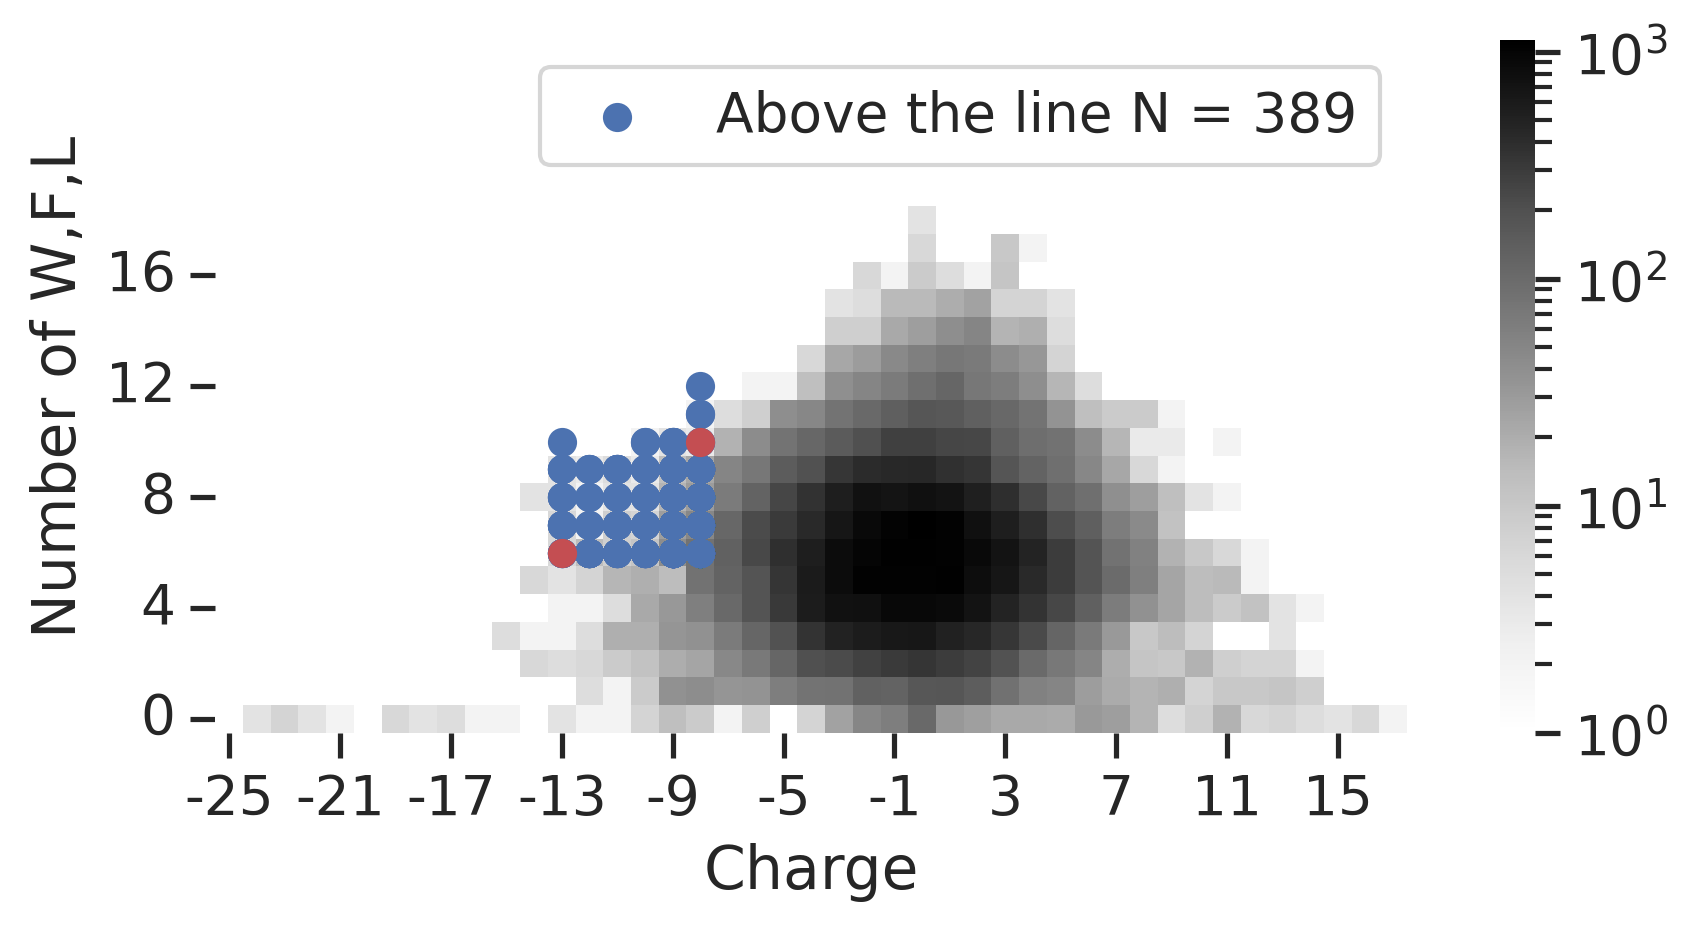

In [90]:
composition_preds = AD_predictor_tools.make_predictions(folder_name="predictions/",
                        inputfilename="arabidopsis_tair.fasta",
                        slope=1,
                        lower_corner_c='VP16',lower_corner_h=6,
                        upper_corner_c=-8,upper_corner_h='CITED2',
                        LowerCorner_slope1='inf', LowerCorner_slope2=0,
                        UpperCorner_slope1='inf', UpperCorner_slope2='inf',
                        composition=['W','F','L'],
                        window_size=39,
                        window_spacing=1,
                        propset=['Charge','AllHydros'])
composition_preds["uniprotID"] = composition_preds["GeneName"]
composition_intervals = composition_preds[["uniprotID", "Start", "End"]]
composition_intervals["predictor"] = "Composition"
composition_intervals

In [91]:
! rm arabidopsis_tair.fasta

In [92]:
composition_preds = pd.read_csv("/global/scratch/projects/fc_mvslab/predictors/Sanjana_predictor/output/predictions/arabidopsis_tair_s_001_lcc_VP16_lch_006_ucc_-08_uch_CITED2_lcs1_inf_lcs2_000_lcs1_inf_ucs2_inf_comp_WFL_tl_039_ws_001_ps1_Charge_ps2_AllHydros")
composition_preds["uniprotID"] = composition_preds["GeneName"]
composition_intervals = composition_preds[["uniprotID", "Start", "End"]]
composition_intervals["predictor"] = "Composition"
composition_intervals

,uniprotID,Start,End,predictor
0,"TAF12B,",532,573,Composition
1,"RGA2,",50,101,Composition
2,AP19,62,110,Composition
3,ESE3,134,177,Composition
4,"SEC1B,",143,188,Composition
5,"SEC1B,",241,283,Composition
6,TAF5,203,265,Composition
7,"QSOX1,",170,214,Composition
8,CYP71B11,241,281,Composition
9,"TAF10,",3,51,Composition


# Combining intervals to consensus traces

In [97]:
all_models = pd.concat([adhunter_intervals, tada_intervals, adpred_intervals, composition_intervals, paddle_intervals])
all_models["Start"] = all_models["Start"].astype(int)
all_models["End"] = all_models["End"].astype(int)
all_models = all_models.rename(columns = {"uniprotID" : "name"})
all_models

,name,Start,End,predictor
0,LUL1,34,92,ADHunter
1,LUL1,173,215,ADHunter
2,"ACAM-2,",30,103,ADHunter
3,KCS17,199,239,ADHunter
4,KCS16,376,416,ADHunter
...,...,...,...,...
115,"WNK9,",432,440,PADDLE
116,"XIB,",465,477,PADDLE
116,"XIB,",1446,1453,PADDLE
116,"XIB,",1454,1473,PADDLE


In [99]:
all_models = pd.merge(all_models, preds[["name", "tair_ID"]]).drop(columns = ["name"])
all_models

,Start,End,predictor,tair_ID
0,34,92,ADHunter,AT5G03200.1
1,173,215,ADHunter,AT5G03200.1
2,34,74,TADA,AT5G03200.1
3,139,228,TADA,AT5G03200.1
4,176,201,PADDLE,AT5G03200.1
...,...,...,...,...
721,194,252,TADA,AT5G25150.1
722,533,584,TADA,AT5G25150.1
723,203,265,Composition,AT5G25150.1
724,207,238,PADDLE,AT5G25150.1


In [100]:
all_models.to_csv("/global/scratch/projects/fc_mvslab/OpenProjects/Sanjana/collaborations/GrENEnet_TF_hits/06_all_prediction_intervals.csv")

In [107]:
pd.DataFrame(all_models["predictor"].value_counts()).reset_index()

,predictor,count
0,TADA,276
1,ADHunter,228
2,ADPred,116
3,PADDLE,59
4,Composition,47


Text(0.5, 1.0, 'Predictions made on GrENEnet Proteins')

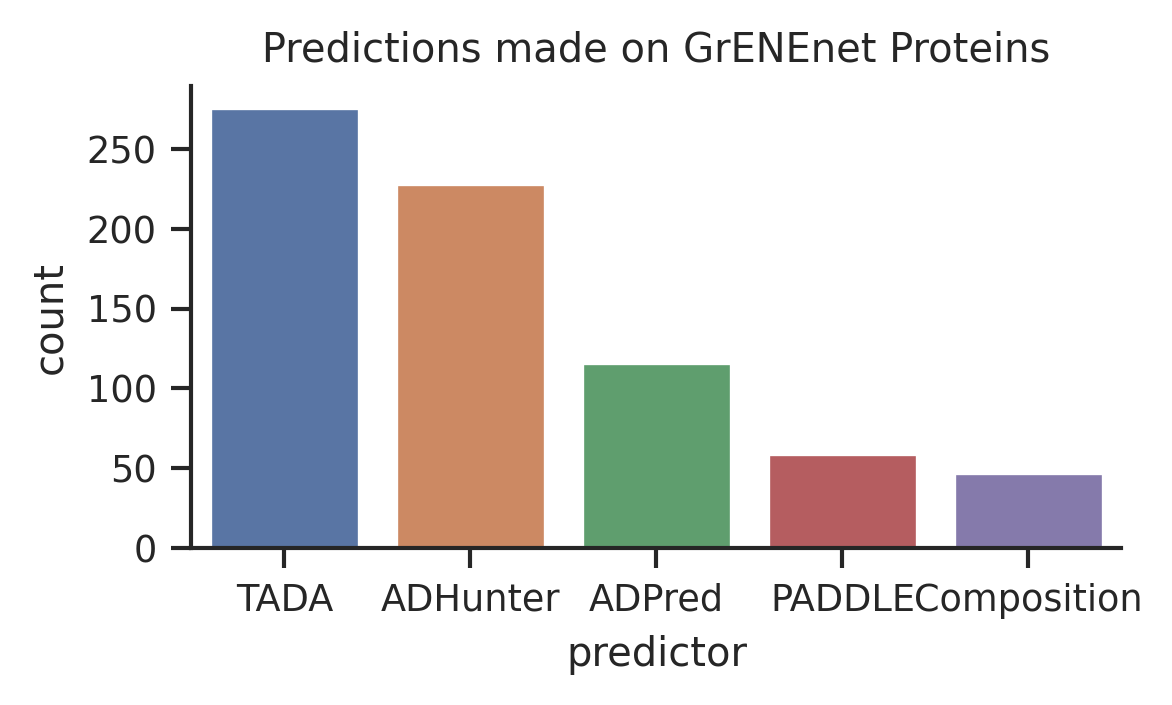

In [119]:
sns.set_context('paper')
plt.figure(dpi = 300, figsize = (4,2))
sns.barplot(data = pd.DataFrame(all_models["predictor"].value_counts()).reset_index(), x= 'predictor', y = 'count')
sns.despine()
plt.title("Predictions made on GrENEnet Proteins")

In [98]:
import os

def plot_all_predictors(preds, index=0, output_folder="predictor_plots"):
    """
    Plots combined and individual predictor traces for a given index from the preds DataFrame,
    and saves each plot to an output folder.

    Parameters:
        preds (pd.DataFrame): DataFrame with predictor outputs and centers.
        index (int): Index of the row to plot.
        output_folder (str): Folder to save the plots.
    """
    # Make output folder if it doesn't exist
    os.makedirs(output_folder, exist_ok=True)
    
    plt.figure(dpi=300, figsize=(10, 3))
    palette = sns.color_palette('colorblind', 5)

    name_clean = preds_with_id['name'].iloc[index].replace(",", "")
    tair_ID = preds_with_id['tair_ID'].iloc[index]
    title = f"{name_clean} | {tair_ID}"

    # Secondary y-axis
    ax2 = sns.lineplot(
        x=preds["paddle_centers"].iloc[index], 
        y=np.array(preds["paddle_preds"].iloc[index]) / 4, 
        label="PADDLE", 
        color=palette[1]
    )
    sns.lineplot(
        x=preds["adhunter_centers"].iloc[index], 
        y=np.array(preds["adhunter_preds"].iloc[index]) / 100000, 
        label="ADHunter", 
        ax=ax2, 
        color=palette[2]
    )
    sns.lineplot(
        x=preds["tada_centers"].iloc[index], 
        y=np.array(preds["tada_preds"].iloc[index]) / 0.4, 
        label="TADA", 
        ax=ax2, 
        color=palette[3]
    )
    sns.lineplot(
        x=range(len(preds["adpred_preds"].iloc[index])), 
        y=np.array(preds["adpred_preds"].iloc[index]) / 0.8, 
        label="ADPred", 
        ax=ax2, 
        color=palette[4]
    )

    # Composition highlights
    prot_uniprotID = preds["uniprotID"].iloc[index]
    compos_preds = composition_intervals[composition_intervals["uniprotID"] == prot_uniprotID]
    for i in compos_preds.index:
        plt.axvspan(compos_preds["Start"].loc[i],
                    compos_preds["End"].loc[i],
                    color='gray', alpha=0.5, label="Composition Pred")

    ax2.axhline(1, linestyle="--", color="gray", linewidth=0.8)

    # Positioning arrows
    xmin, xmax = ax2.get_xlim()
    x_pos = xmin + 0.95 * (xmax - xmin)
    ymin, ymax = ax2.get_ylim()
    yrange = ymax - ymin
    up_tip = 1 + 0.15 * yrange
    down_tip = 1 - 0.15 * yrange

    # Expand ylim so arrows are visible
    ax2.set_ylim(
        min(ymin, down_tip - 0.05 * yrange),
        max(ymax, up_tip + 0.05 * yrange)
    )

    # Active arrow
    ax2.annotate(
        '',
        xy=(x_pos, up_tip),
        xytext=(x_pos, 1),
        arrowprops=dict(arrowstyle='-|>', color='0.4', lw=1.2)
    )
    ax2.text(x_pos, up_tip + 0.02*yrange, "Active",
             ha='center', va='bottom', fontsize=10, color='0.4')

    # Inactive arrow
    ax2.annotate(
        '',
        xy=(x_pos, down_tip),
        xytext=(x_pos, 1),
        arrowprops=dict(arrowstyle='-|>', color='0.4', lw=1.2)
    )
    ax2.text(x_pos, down_tip - 0.02*yrange, "Inactive",
             ha='center', va='top', fontsize=10, color='0.4')

    ax2.legend(bbox_to_anchor=(1, 1))
    ax2.set_title(title)
    sns.despine()
    plt.tight_layout()

    # Save the plot
    safe_name = f"{name_clean}_{tair_ID}.png"
    save_path = os.path.join(output_folder, safe_name)
    plt.savefig(save_path, dpi=300, bbox_inches = 'tight')
    plt.close()

In [99]:
for i in tqdm(preds.index):
    plot_all_predictors(preds, i, "/global/scratch/projects/fc_mvslab/OpenProjects/Sanjana/collaborations/GrENEnet_TF_hits/07_activity_traces")
    plt.show()

100%|██████████| 119/119 [01:00<00:00,  1.96it/s]


In [102]:
preds.to_csv("/global/scratch/projects/fc_mvslab/OpenProjects/Sanjana/collaborations/GrENEnet_TF_hits/04_predictor_results/all_preds.csv")